In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from ucimlrepo import fetch_ucirepo 

In [2]:
RANDOM_STATE = 12345

# Load data
**Bank Marketing data** is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).

In [31]:
bank_marketing = fetch_ucirepo(name='Bank Marketing') 

In [32]:
X = bank_marketing.data.features 
y = bank_marketing.data.targets
X.shape, y.shape

((45211, 16), (45211, 1))

In [33]:
y['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [34]:
missing_pct = X.isna().mean().mul(100).sort_values(ascending=False)
missing_pct

poutcome       81.747805
contact        28.798301
education       4.107407
job             0.637013
age             0.000000
marital         0.000000
default         0.000000
balance         0.000000
housing         0.000000
loan            0.000000
day_of_week     0.000000
month           0.000000
duration        0.000000
campaign        0.000000
pdays           0.000000
previous        0.000000
dtype: float64

In [35]:
# Numeric columns with at least one missing value
numeric_missing_cols = (
    X.select_dtypes(include="number")
      .columns[X.select_dtypes(include="number").isna().any()]
      .tolist()
)

# Non-numeric columns with at least one missing value
non_numeric_missing_cols = (
    X.select_dtypes(exclude="number")
      .columns[X.select_dtypes(exclude="number").isna().any()]
      .tolist()
)

print(f'numeric_missing_cols = {numeric_missing_cols}')
print(f'non_numeric_missing_cols = {non_numeric_missing_cols}')

numeric_missing_cols = []
non_numeric_missing_cols = ['job', 'education', 'contact', 'poutcome']


In [36]:
X[numeric_missing_cols] = X[numeric_missing_cols].fillna(-9999999)
X[non_numeric_missing_cols] = X[non_numeric_missing_cols].fillna("unknown")

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=RANDOM_STATE)

print('Train', X_train.shape, y_train.shape)
print('Valid', X_valid.shape, y_valid.shape)
print('Test', X_test.shape, y_test.shape)

Train (36168, 16) (36168, 1)
Valid (4521, 16) (4521, 1)
Test (4522, 16) (4522, 1)


In [38]:
# DecisionTreeClassifier in scikit-learn expects numerical input.
# Convert non-numerical features to numerical features by OneHotEncoder

numeric_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(exclude="number").columns

encoder = OneHotEncoder(
    handle_unknown="ignore",  # Ignore categories that only appear in the test set
    sparse_output=False
)
encoder.set_output(transform='pandas')
encoder.fit(X_train[categorical_cols])

X_train_dummy = encoder.transform(X_train[categorical_cols])
X_valid_dummy = encoder.transform(X_valid[categorical_cols])
X_test_dummy = encoder.transform(X_test[categorical_cols])

X_train = pd.concat([X_train[numeric_cols], X_train_dummy], axis=1)
X_valid = pd.concat([X_valid[numeric_cols], X_valid_dummy], axis=1)
X_test = pd.concat([X_test[numeric_cols], X_test_dummy], axis=1)

print('Train', X_train.shape, y_train.shape)
print('Valid', X_valid.shape, y_valid.shape)
print('Test', X_test.shape, y_test.shape)

Train (36168, 51) (36168, 1)
Valid (4521, 51) (4521, 1)
Test (4522, 51) (4522, 1)


In [39]:
X_train.head()

,age,balance,day_of_week,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
16511,49,-57,23,161,2,-1,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16847,39,276,25,441,12,-1,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10833,44,-82,17,181,1,-1,0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
34634,41,-298,5,397,1,-1,0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24117,27,185,31,18,1,-1,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [40]:
y_train.head()

,y
16511,no
16847,no
10833,no
34634,no
24117,no


# DecisionTreeClassifier

In [51]:
classifier = DecisionTreeClassifier(
    max_depth=3,
    criterion='gini',                # Gini impurity
    splitter='best',                 # choose the best split
    random_state=RANDOM_STATE,
)

classifier.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",12345
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [52]:
feature_cols = list(X_train.columns)
target_cols = list(y_train.columns)

In [53]:
text_representation = export_text(classifier, feature_names=feature_cols)
print(text_representation)

|--- duration <= 472.50
|   |--- poutcome_success <= 0.50
|   |   |--- month_mar <= 0.50
|   |   |   |--- class: no
|   |   |--- month_mar >  0.50
|   |   |   |--- class: no
|   |--- poutcome_success >  0.50
|   |   |--- duration <= 132.50
|   |   |   |--- class: no
|   |   |--- duration >  132.50
|   |   |   |--- class: yes
|--- duration >  472.50
|   |--- duration <= 807.50
|   |   |--- poutcome_success <= 0.50
|   |   |   |--- class: no
|   |   |--- poutcome_success >  0.50
|   |   |   |--- class: yes
|   |--- duration >  807.50
|   |   |--- marital_married <= 0.50
|   |   |   |--- class: yes
|   |   |--- marital_married >  0.50
|   |   |   |--- class: yes



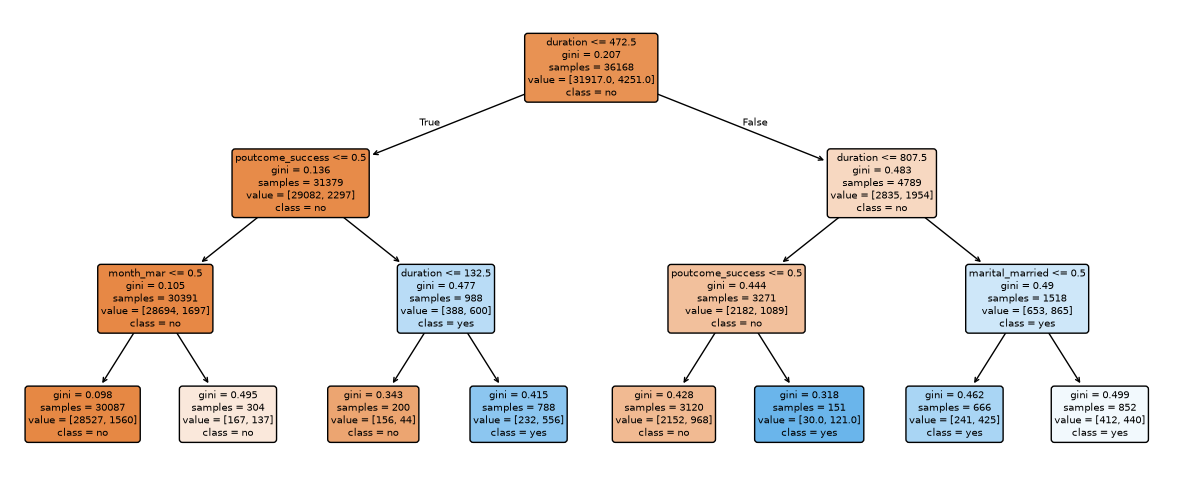

In [59]:
plt.figure(figsize=(15, 6))
plot_tree(
    classifier, 
    feature_names=feature_cols, 
    class_names=classifier.classes_, 
    filled=True, 
    rounded=True
)
plt.show()

# Algorithm

1. **For each feature,** sort the samples at the current node by that feature's value.
2. **For each possible threshold** between consecutive sorted values, consider splitting the node into a "left" group (values ≤ threshold) and a "right" group (values > threshold).
3. **Compute the impurity** of each resulting group using a criterion e.g. **gini**.
4. **Score the split** by how much it reduces impurity compared to the parent node, weighted by the number of samples in each child.
5. **Repeat across all features and thresholds**, and choose the single split (feature + threshold) that gives the largest impurity reduction.

In [62]:
def gini_impurity(y):
    """
    Compute Gini impurity for a set of labels.
    Gini = 1 - sum(p_i^2) for each class i
    """
    y = np.asarray(y)
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return 1 - np.sum(probabilities ** 2)

def weighted_gini(y_left, y_right):
    n_left, n_right = len(y_left), len(y_right)
    n_total = n_left + n_right
    return (n_left / n_total) * gini_impurity(y_left) + (n_right / n_total) * gini_impurity(y_right)

In [68]:
def find_best_split(X, y, feature_cols):
    parent_impurity = gini_impurity(y)

    min_impurity = 1e9
    best_feature_idx = None
    best_feature = None
    best_thres = None
    
    for idx in range(len(feature_cols)):
        # For each feature, sort unique values
        Xf = X[:, idx]
        sort_unq_Xf = np.sort(np.unique(Xf))

        # find possible threshold between consecutive sorted values
        possible_threshold = (sort_unq_Xf[:-1] + sort_unq_Xf[1:])/2 

        for thres in possible_threshold:
            # For each possible threshold, splitting the node into a "left" group and a "right" group
            left_grp = y[Xf <= thres]
            right_grp = y[Xf > thres]

            # Compute the impurity
            impurity = weighted_gini(left_grp, right_grp)

            # choose the single split that gives the largest impurity reduction.
            if (impurity < min_impurity) and (impurity < parent_impurity):
                min_impurity = impurity
                best_feature_idx = idx
                best_feature = feature_cols[idx]
                best_thres = thres
                best_left_grp = [X[Xf <= thres,:], left_grp]
                best_right_grp = [X[Xf > thres,:], right_grp]

    return best_feature, best_thres, best_left_grp, best_right_grp

In [70]:
f, thres, left_grp, right_grp = find_best_split(X_train.values, y_train.values, feature_cols)
print(f'|--- {f} <= {thres:.2f}')

f, thres, left_grp10, right_grp10 = find_best_split(left_grp[0], left_grp[1], feature_cols)
print(f'|   |--- {f} <= {thres:.2f}')

f, thres, left_grp100, right_grp100 = find_best_split(left_grp10[0], left_grp10[1], feature_cols)
print(f'|   |   |--- {f} <= {thres:.2f}')

f, thres, left_grp101, right_grp101 = find_best_split(right_grp10[0], right_grp10[1], feature_cols)
print(f'|   |   |--- {f} <= {thres:.2f}')

|--- duration <= 472.50
|   |--- poutcome_success <= 0.50
|   |   |--- month_mar <= 0.50
|   |   |--- duration <= 132.50


In [71]:
f, thres, left_grp, right_grp = find_best_split(X_train.values, y_train.values, feature_cols)
print(f'|--- {f} > {thres:.2f}')

f, thres, left_grp01, right_grp01 = find_best_split(right_grp[0], right_grp[1], feature_cols)
print(f'|   |--- {f} <= {thres:.2f}')

f, thres, left_grp010, right_grp010 = find_best_split(left_grp01[0], left_grp01[1], feature_cols)
print(f'|   |   |--- {f} <= {thres:.2f}')

f, thres, left_grp011, right_grp101 = find_best_split(right_grp01[0], right_grp01[1], feature_cols)
print(f'|   |   |--- {f} <= {thres:.2f}')

|--- duration > 472.50
|   |--- duration <= 807.50
|   |   |--- poutcome_success <= 0.50
|   |   |--- marital_married <= 0.50
